# TP2 — Segmentation RFM & Recommandations marketing — Lumina & Co

**Cours :** Data Marketing et Analytics — DIA2 — HETIC
**Jour 2 :** *"Qui sont nos clients ?"*

Le Jour 1 a répondu à la première question du CMO (non, on ne peut pas traiter tout le monde pareil) et a produit
une base nettoyée et documentée. Aujourd'hui, on construit une segmentation RFM (Récence, Fréquence, Montant)
actionnable, avec pour chaque segment un profil, un potentiel, un risque et une recommandation concrète.

Ce notebook suit 4 étapes :
1. Construction des features RFM
2. Scoring RFM (quintiles) et définition des segments
3. Visualisation et profilage démographique
4. Recommandations marketing par segment, priorisées

## Étape 0 — Rechargement et nettoyage (reprise du Jour 1)

On repart de `customers.csv` et `transactions.csv` bruts, et on réapplique exactement les décisions de nettoyage
du TP1 : suppression des 445 doublons stricts, calcul de `line_total`, exclusion des lignes `Frais` et des lignes
à quantité ou prix non positifs pour obtenir `product_sales` — le sous-ensemble de ventes produit valorisées sur
lequel on calcule tout indicateur monétaire, exactement comme au Jour 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

%matplotlib inline
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PALETTE = {
    "primary": "#5B4FCF",
    "secondary": "#2FB4A6",
    "warn": "#E0793C",
    "bad": "#D64550",
    "neutral": "#8891A5",
}
SEGMENT_COLORS = {
    "Champions": "#5B4FCF",
    "Fideles": "#2FB4A6",
    "A risque": "#E0793C",
    "A surveiller": "#8891A5",
    "Nouveaux / Prometteurs": "#4C9BE0",
    "Hibernants": "#B7A8E8",
    "Gros paniers occasionnels": "#E0C23C",
    "Perdus": "#D64550",
}

In [2]:
customers = pd.read_csv("Lumina & Co - CRM/customers.csv")
transactions = pd.read_csv("Lumina & Co - CRM/transactions.csv")

customers["first_purchase"] = pd.to_datetime(customers["first_purchase"])
customers["last_purchase"] = pd.to_datetime(customers["last_purchase"])
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])

# --- reprise des décisions de nettoyage du TP1 ---
transactions = transactions[~transactions.duplicated(keep="first")].reset_index(drop=True)
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]
transactions["is_fee_or_adjustment"] = transactions["category"].eq("Frais")

product_sales = transactions[
    (~transactions["is_fee_or_adjustment"])
    & (transactions["quantity"] > 0)
    & (transactions["unit_price"] > 0)
].copy()

print(f"transactions (dédupliquées) : {len(transactions):,} lignes".replace(",", " "))
print(f"product_sales (ventes valorisées) : {len(product_sales):,} lignes".replace(",", " "))

transactions (dédupliquées) : 1 612 988 lignes
product_sales (ventes valorisées) : 1 566 708 lignes


## Étape 1 — Construction des features RFM

### Date de référence (snapshot date)

Le dataset s'arrête le **30 juin 2026** (date max de `invoice_date`). Utiliser `pd.Timestamp.now()` calculerait
une récence artificiellement gonflée de plusieurs mois pour *tout le monde* — ce n'est pas une erreur qui touche
un segment plus qu'un autre, elle décale uniformément toute l'échelle de récence, ce qui casserait le scoring par
quintiles autant que les seuils métier qu'on posera plus loin. On fixe donc une fois pour toutes :

**`snapshot_date = transactions["invoice_date"].max()`**, calculée sur `transactions` (toutes lignes, avant filtre
`product_sales`) pour être sûr de capturer la date la plus tardive présente dans l'export, retours et frais compris.

In [3]:
snapshot_date = transactions["invoice_date"].max()
print(f"snapshot_date : {snapshot_date.date()}")

snapshot_date : 2026-06-30


### Calcul des features

- **Récence** : jours entre la dernière vente produit valorisée du client et `snapshot_date`.
- **Fréquence** : nombre de factures (`invoice_id`) distinctes sur `product_sales`.
- **Montant** : somme de `line_total` sur `product_sales`.

On calcule tout depuis `product_sales` plutôt que depuis les agrégats de `customers.csv`, pour la même raison
documentée au Jour 1 : ces agrégats pré-calculés ne se reconstituent pas depuis les transactions et ne sont pas
fiables. On restreint aussi aux lignes avec `customer_id` connu (les ventes sans client, 22.8 % du volume,
restent incluses dans le CA global de l'entreprise mais ne peuvent par définition entrer dans un profil client).

**Deux features complémentaires** ajoutées, utiles pour le profilage (étape 3-4) sans faire partie du scoring RFM :
- `avg_basket` = montant / fréquence (montant moyen par facture)
- `tenure_days` = ancienneté depuis la première vente produit valorisée jusqu'à `snapshot_date`

In [4]:
sales_id = product_sales.dropna(subset=["customer_id"]).copy()
sales_id["customer_id"] = sales_id["customer_id"].astype(int)

rfm = sales_id.groupby("customer_id").agg(
    recency=("invoice_date", lambda s: (snapshot_date - s.max()).days),
    frequency=("invoice_id", "nunique"),
    monetary=("line_total", "sum"),
    first_purchase_recalc=("invoice_date", "min"),
).reset_index()

rfm["avg_basket"] = rfm["monetary"] / rfm["frequency"]
rfm["tenure_days"] = (snapshot_date - rfm["first_purchase_recalc"]).dt.days

print(f"Clients avec au moins une vente produit valorisée : {len(rfm):,} / {len(customers):,}".replace(",", " "))
rfm[["recency", "frequency", "monetary", "avg_basket", "tenure_days"]].describe().round(1)

Clients avec au moins une vente produit valorisée : 49 190 / 50 295


,recency,frequency,monetary,avg_basket,tenure_days
count,49190.0,49190.0,49190.0,49190.0,49190.0
mean,312.1,4.4,813.0,154.9,539.2
std,295.4,5.7,4161.1,307.2,299.1
min,0.0,1.0,6.2,6.2,0.0
25%,72.0,1.0,101.6,54.0,315.0
50%,207.0,3.0,243.3,78.3,560.0
75%,489.0,6.0,570.7,112.5,731.0
max,1635.0,373.0,416423.6,9876.5,1635.0


**1 105 clients de `customers.csv` (2,2 % de la base) n'ont aucune ligne dans `product_sales`** : soit ils
n'ont que des retours/frais (aucune vente positive valorisée), soit ils font partie des 983 clients du Jour 1 sans
aucune transaction du tout. On les **exclut de la segmentation RFM** — on ne peut pas calculer une récence ou un
montant pour quelqu'un sans vente valorisée — mais ils ne doivent pas être traités comme "inexistants" pour
autant : ce sont probablement des clients dont l'unique achat a été intégralement retourné, une population à
part à surveiller plutôt qu'à ignorer.

## Étape 2 — Scoring RFM et segments

### Scores R, F, M par quintiles (1 à 5)

On découpe chaque dimension en 5 groupes de taille égale (quintiles). Pour la **récence**, on inverse l'échelle :
un client récent (peu de jours écoulés) doit avoir le score le plus haut (5), donc on associe les labels
`[5, 4, 3, 2, 1]` aux quintiles croissants de `recency`.

In [5]:
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

print("Bornes des quintiles — récence (jours) :")
print(pd.qcut(rfm["recency"], 5).cat.categories)
print("\nBornes des quintiles — montant (€) :")
print(pd.qcut(rfm["monetary"], 5).cat.categories.map(lambda i: f"{i.left:,.0f}€ – {i.right:,.0f}€".replace(",", " ")))

Bornes des quintiles — récence (jours) :
IntervalIndex([(-0.001, 56.0], (56.0, 136.0], (136.0, 308.0], (308.0, 561.0], (561.0, 1635.0]], dtype='interval[float64, right]')

Bornes des quintiles — montant (€) :
Index(['6€ – 81€', '81€ – 175€', '175€ – 337€', '337€ – 700€', '700€ – 416 424€'], dtype='str')


### Le score F pose un problème que R et M ne posent pas

`recency` et `monetary` sont des variables quasi continues : `qcut` trouve 5 groupes de taille à peu près égale
sans ambiguïté. `frequency` est un entier avec une masse énorme sur les petites valeurs : **29,7 % des clients
n'ont acheté qu'une seule fois**, et 17,4 % en ont acheté exactement deux. Le premier quintile (20 % de la base)
est donc *entièrement* composé de clients à fréquence 1, et le second quintile mélange nécessairement des
fréquence-1 et des fréquence-2 — `qcut` doit trancher arbitrairement *lequel* des clients à fréquence 1 va dans le
quintile 1 vs 2, puisqu'ils sont, sur ce critère, strictement identiques.

**Décision :** on utilise `rank(method="first")` pour départager les ex-æquo avant de découper en quintiles.
C'est une convention technique nécessaire pour que le code s'exécute, mais elle introduit un peu d'arbitraire
dans la frontière F=1/F=2 — **limite à documenter**, pas un vrai signal métier. On vérifie ci-dessous que les
bornes obtenues restent interprétables (F=1 → 1 commande, F=5 → 7 commandes ou plus).

In [6]:
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

print("Bornes effectives du score F (nb de commandes) :")
print(rfm.groupby("F")["frequency"].agg(["min", "max", "count"]))

rfm["RFM_score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)
rfm["RFM_sum"] = rfm["R"] + rfm["F"] + rfm["M"]

Bornes effectives du score F (nb de commandes) :
   min  max  count
F                 
1    1    1   9838
2    1    2   9838
3    2    4   9838
4    4    7   9838
5    7  373   9838


### Distribution des scores et matrice RFM

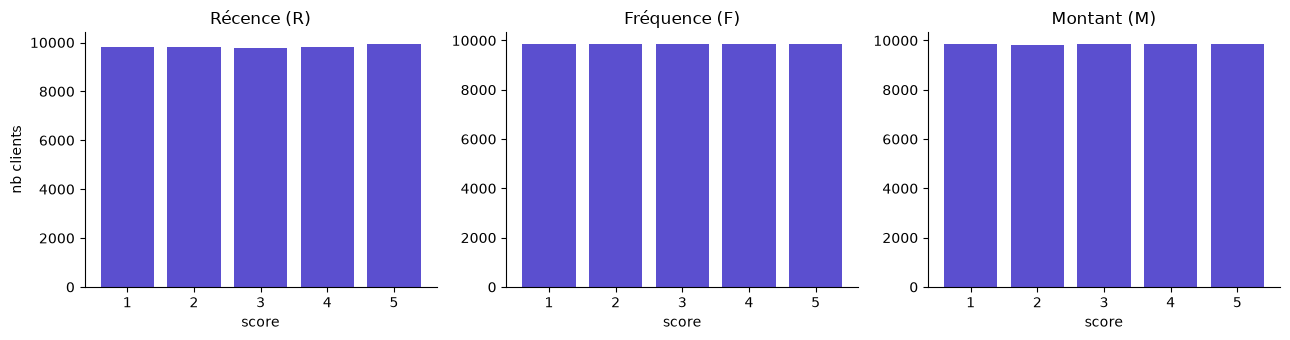

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col, label in zip(axes, ["R", "F", "M"], ["Récence (R)", "Fréquence (F)", "Montant (M)"]):
    counts = rfm[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=PALETTE["primary"])
    ax.set_title(label)
    ax.set_xlabel("score")
    ax.set_xticks([1, 2, 3, 4, 5])
axes[0].set_ylabel("nb clients")
plt.tight_layout()
plt.show()

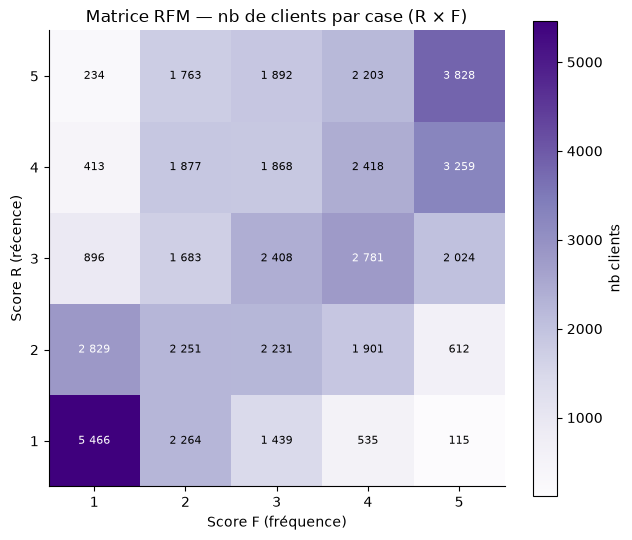

In [8]:
rfm_matrix = rfm.pivot_table(index="R", columns="F", values="customer_id", aggfunc="count").fillna(0).astype(int)
rfm_matrix = rfm_matrix.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(rfm_matrix.values, cmap="Purples")
ax.set_xticks(range(len(rfm_matrix.columns)))
ax.set_xticklabels(rfm_matrix.columns)
ax.set_yticks(range(len(rfm_matrix.index)))
ax.set_yticklabels(rfm_matrix.index)
ax.set_xlabel("Score F (fréquence)")
ax.set_ylabel("Score R (récence)")
ax.set_title("Matrice RFM — nb de clients par case (R × F)")
for i in range(rfm_matrix.shape[0]):
    for j in range(rfm_matrix.shape[1]):
        v = rfm_matrix.values[i, j]
        ax.text(j, i, f"{v:,}".replace(",", " "), ha="center", va="center",
                color="white" if v > rfm_matrix.values.max() * 0.5 else "black", fontsize=8)
fig.colorbar(im, ax=ax, label="nb clients")
plt.tight_layout()
plt.show()

**Lecture de la matrice :** le coin haut-droite (R=5, F=5, forte récence et forte fréquence) et le coin
bas-gauche (R=1, F=1) sont les deux pôles attendus d'une segmentation RFM — clients très engagés vs. clients
inactifs. On voit aussi une concentration notable sur la ligne F=1 (colonne la plus peuplée), cohérente avec les
29,7 % d'acheteurs uniques identifiés au Jour 1.

### Les 3 questions du CMO — cas extrêmes

In [9]:
total_revenue = rfm["monetary"].sum()

champions_555 = rfm[rfm["RFM_score"] == "555"]
champions_large = rfm[(rfm["R"] >= 4) & (rfm["F"] >= 4) & (rfm["M"] >= 4)]

print("=== Champions ===")
print(f"Score exact 555           : {len(champions_555):,} clients ({len(champions_555)/len(rfm)*100:.1f} %), "
      f"{champions_555['monetary'].sum()/total_revenue*100:.1f} % du CA".replace(",", " "))
print(f"R,F,M tous >= 4 (élargi)   : {len(champions_large):,} clients ({len(champions_large)/len(rfm)*100:.1f} %), "
      f"{champions_large['monetary'].sum()/total_revenue*100:.1f} % du CA".replace(",", " "))

=== Champions ===
Score exact 555           : 2 969 clients (6.0 %)  41.4 % du CA
R F M tous >= 4 (élargi)   : 10 111 clients (20.6 %)  64.0 % du CA


**Champions :** seulement **2 969 clients** (6,0 % de la base) ont le score parfait 555 — mais ils pèsent déjà
**41,4 % du chiffre d'affaires total**. En élargissant à R, F et M tous ≥ 4 (une définition plus réaliste du
"cœur de clientèle fidèle et rentable", incluant les clients à un cran du score parfait), on passe à **10 111
clients (20,6 % de la base) pour 64,0 % du CA**. Les deux lectures pointent dans la même direction : une
minorité de clients porte l'essentiel du chiffre d'affaires — cohérent avec la courbe de Pareto du Jour 1.

In [10]:
at_risk = rfm[(rfm["R"] <= 2) & (rfm["M"] >= 4)]
print("=== À risque (forte valeur historique, faible récence) ===")
print(f"R <= 2 et M >= 4 : {len(at_risk):,} clients ({len(at_risk)/len(rfm)*100:.1f} % de la base)".replace(",", " "))
print(f"CA historique cumulé : {at_risk['monetary'].sum():,.0f} € ({at_risk['monetary'].sum()/total_revenue*100:.1f} % du CA)".replace(",", " "))
print(f"Récence médiane : {at_risk['recency'].median():.0f} jours depuis le dernier achat")

=== À risque (forte valeur historique, faible récence) ===
R <= 2 et M >= 4 : 3 744 clients (7.6 % de la base)
CA historique cumulé : 3 871 436 € (9.7 % du CA)
Récence médiane : 446 jours depuis le dernier achat


**À risque :** **3 744 clients (7,6 % de la base)** ont un historique de dépense dans le top 40 % (M ≥ 4)
mais n'ont pas acheté depuis longtemps (R ≤ 2, donc parmi les 40 % les moins récents — récence médiane de
**446 jours**, plus d'un an). Ils représentent **9,7 % du CA historique** : c'est de la valeur déjà prouvée qui
est en train de s'éteindre silencieusement, sans qu'aucun signal (plainte, désabonnement) ne l'annonce. C'est le
segment où un euro de rétention dépensé a le meilleur ROI attendu, parce que le comportement d'achat futur est
déjà démontré par le passé — contrairement à un prospect.

*(Cette définition stricte "R≤2 et M≥4" isole les cas les plus évidents. La règle de segmentation à 8 groupes
plus bas élargit à "R≤2 et (F≥4 ou M≥4)" — ce qui fait passer ce segment à 4 835 clients / 10,3 % du CA — pour
capturer aussi les clients à forte fréquence mais petit panier moyen, tout aussi menacés de churn.)*

In [11]:
lost = rfm[rfm["RFM_score"] == "111"]
print("=== Perdus (111) ===")
print(f"{len(lost):,} clients ({len(lost)/len(rfm)*100:.1f} % de la base)".replace(",", " "))
print(f"CA cumulé : {lost['monetary'].sum():,.0f} € ({lost['monetary'].sum()/total_revenue*100:.2f} % du CA)".replace(",", " "))
print(f"Montant total dépensé médian : {lost['monetary'].median():.0f} €, fréquence : {lost['frequency'].median():.0f} commande(s)")

=== Perdus (111) ===
3 155 clients (6.4 % de la base)
CA cumulé : 129 776 € (0.32 % du CA)
Montant total dépensé médian : 40 €, fréquence : 1 commande(s)


**Perdus (111) :** **3 155 clients (6,4 % de la base)**, mais seulement **0,3 % du CA**. Contrairement au
segment "à risque", ce sont des clients qui n'ont *jamais* eu de valeur : un seul petit achat, il y a longtemps,
jamais renouvelé. **Action recommandée : exclusion des campagnes d'acquisition/rétention coûteuses** (email
personnalisé, offre remise, retargeting payant). Le coût d'acquisition ou de réactivation dépasserait
vraisemblablement la valeur qu'on peut espérer récupérer. Tout au plus, un email automatisé low-cost
("On ne vous a pas revu…") sans effort créatif ni budget média, pour ne pas fermer complètement la porte à un
retour spontané.

### Au-delà des 3 cas extrêmes : une segmentation à 8 groupes

R=555, R=111 et "à risque" ne couvrent à eux trois que 22,2 % de la base — il faut des règles pour le reste.
On construit une segmentation en 8 segments par des règles ordonnées sur (R, F, M), documentées et justifiées
ci-dessous. L'ordre des règles compte : chaque client tombe dans le **premier** segment dont il remplit la
condition.

| # | Segment | Règle | Logique métier |
|---|---|---|---|
| 1 | **Champions** | R≥4, F≥4, M≥4 | Récents, réguliers, gros contributeurs — le noyau dur. |
| 2 | **Fidèles** | R≥3, F≥3, M≥3 | Encore engagés sur les 3 dimensions, sans être au sommet — la classe "moyenne haute". |
| 3 | **Nouveaux / Prometteurs** | R≥4, F≤2 | Achat très récent mais peu d'historique — trop tôt pour juger la fidélité, mais le signal d'entrée est bon. |
| 4 | **À risque** | R≤2, et (F≥4 ou M≥4) | Valeur prouvée par le passé (fréquence ou montant élevés) mais absence récente — urgence de rétention. |
| 5 | **Perdus** | R=1, F=1, M=1 | Aucune valeur, aucune récence — cas extrême du bas. |
| 6 | **Hibernants** | R≤2, F≤2, M≤2 | Faibles partout et inactifs, mais pas au plancher absolu comme "Perdus" — dormants plutôt que perdus. |
| 7 | **Gros paniers occasionnels** | M≥4, F≤2 | Rares mais très gros achats (paniers B2B/comité d'entreprise identifiés au Jour 1 en partie) — cross/upsell plutôt que fréquence. |
| 8 | **À surveiller** | *(tout le reste)* | Comportement médian sur toutes les dimensions — ni signal fort positif, ni négatif. |

**Pourquoi ces seuils et cet ordre ?** Les règles 1 et 5 traitent d'abord les deux pôles (déjà validés par le
CMO). La règle 3 est testée avant "Hibernants"/"À surveiller" pour ne pas confondre un client *nouveau* (peu de
temps pour accumuler de la fréquence, R élevé) avec un client *en déclin* (R faible) — un nouveau client à F=1
n'a structurellement pas encore pu prouver sa fidélité, ce n'est pas un signal négatif. La règle 4 utilise un
**"ou"** (F≥4 ou M≥4) plutôt qu'un "et" : un client qui achetait très souvent (F≥4) mais avec de petits paniers,
ou l'inverse, mérite tout autant une alerte de rétention qu'un client fort sur les deux — on ne veut pas rater
l'un des deux profils en étant trop restrictif.

In [12]:
def segment_customer(row):
    R, F, M = row["R"], row["F"], row["M"]
    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"
    if R >= 3 and F >= 3 and M >= 3:
        return "Fideles"
    if R >= 4 and F <= 2:
        return "Nouveaux / Prometteurs"
    if R <= 2 and (F >= 4 or M >= 4):
        return "A risque"
    if R == 1 and F == 1 and M == 1:
        return "Perdus"
    if R <= 2 and F <= 2 and M <= 2:
        return "Hibernants"
    if M >= 4 and F <= 2:
        return "Gros paniers occasionnels"
    return "A surveiller"

rfm["segment"] = rfm.apply(segment_customer, axis=1)

seg_stats = rfm.groupby("segment").agg(
    n_clients=("customer_id", "count"),
    revenue=("monetary", "sum"),
    recency_median=("recency", "median"),
    frequency_median=("frequency", "median"),
).sort_values("revenue", ascending=False)
seg_stats["%_clients"] = (seg_stats["n_clients"] / len(rfm) * 100).round(1)
seg_stats["%_CA"] = (seg_stats["revenue"] / total_revenue * 100).round(1)

assert seg_stats["n_clients"].sum() == len(rfm)  # tous les clients sont classés une fois et une seule
seg_stats[["n_clients", "%_clients", "revenue", "%_CA", "recency_median", "frequency_median"]].round(1)

,n_clients,%_clients,revenue,%_CA,recency_median,frequency_median
segment,,,,,,
Champions,10111,20.6,25582072.6,64.0,53.0,9.0
Fideles,9535,19.4,6344282.1,15.9,160.0,4.0
A risque,4835,9.8,4137023.4,10.3,448.0,4.0
A surveiller,10089,20.5,1538620.3,3.8,297.0,2.0
Nouveaux / Prometteurs,4287,8.7,1282933.9,3.2,61.0,1.0
Hibernants,6830,13.9,611021.9,1.5,551.0,1.0
Gros paniers occasionnels,348,0.7,365121.8,0.9,226.0,2.0
Perdus,3155,6.4,129776.5,0.3,803.0,1.0


**8 segments, et la somme retombe bien sur les 49 190 clients RFM** (vérifié par l'`assert`). On retrouve les
3 segments imposés (Champions 20,6 %/64,0 % CA, À risque 9,8 %/10,3 % CA, Perdus 6,4 %/0,3 % CA — cohérents avec
les calculs isolés plus haut, aux frontières de règles près) et 5 segments supplémentaires qui couvrent le reste :
"À surveiller" (20,5 % de la base, la zone grise médiane), "Fidèles" (19,4 %, 15,9 % du CA — le vivier de futurs
Champions), "Hibernants" (13,9 %, quasi aucune valeur), "Nouveaux/Prometteurs" (8,7 %, encore trop tôt pour
juger) et "Gros paniers occasionnels" (0,7 % seulement, mais un profil comportemental très distinct — cf.
Étape 4).

## Étape 3 — Visualisation et profilage

### Profil démographique par segment

In [13]:
rfm_full = rfm.merge(
    customers[["customer_id", "country", "declared_preference", "age_bracket", "life_stage", "urban_density"]],
    on="customer_id", how="left",
)

profile = rfm_full.groupby("segment").agg(
    n_clients=("customer_id", "count"),
    tenure_median_days=("tenure_days", "median"),
    pct_france=("country", lambda s: (s == "France").mean() * 100),
).round(1)
profile["tenure_median_years"] = (profile["tenure_median_days"] / 365).round(1)
profile.sort_values("n_clients", ascending=False)

,n_clients,tenure_median_days,pct_france,tenure_median_years
segment,,,,
Champions,10111,571.0,91.6,1.6
A surveiller,10089,463.0,91.6,1.3
Fideles,9535,501.0,90.1,1.4
Hibernants,6830,608.0,91.2,1.7
A risque,4835,750.0,93.4,2.1
Nouveaux / Prometteurs,4287,71.0,88.5,0.2
Perdus,3155,803.0,93.7,2.2
Gros paniers occasionnels,348,281.0,91.1,0.8


**Répartition géographique quasi identique dans tous les segments (~90-92 % France partout)** : cohérent avec
le biais géographique déjà documenté au Jour 1 — le pays ne différencie pas les segments RFM entre eux, la
concentration France touche uniformément toute la base. **L'ancienneté (`tenure_median_days`), en revanche, varie
nettement** : les "Nouveaux/Prometteurs" ont une ancienneté médiane très faible (quelques mois, cohérent avec la
définition du segment), alors que "Perdus" et "À risque" ont les anciennetés les plus élevées — ce sont des
comptes anciens qui ont eu le temps de construire, puis de perdre, une relation avec la marque.

### Récence × Montant, coloré par segment

**Attention à la non-linéarité :** un client très récent avec un seul gros achat et un client ancien avec de
nombreux achats répétés peuvent tous deux afficher un fort montant — la relation entre récence et valeur n'est pas
une simple droite décroissante. Le nuage de points ci-dessous (axe montant en échelle log à cause de l'extrême
asymétrie déjà documentée au Jour 1) doit se lire par couleur de segment, pas par position seule.

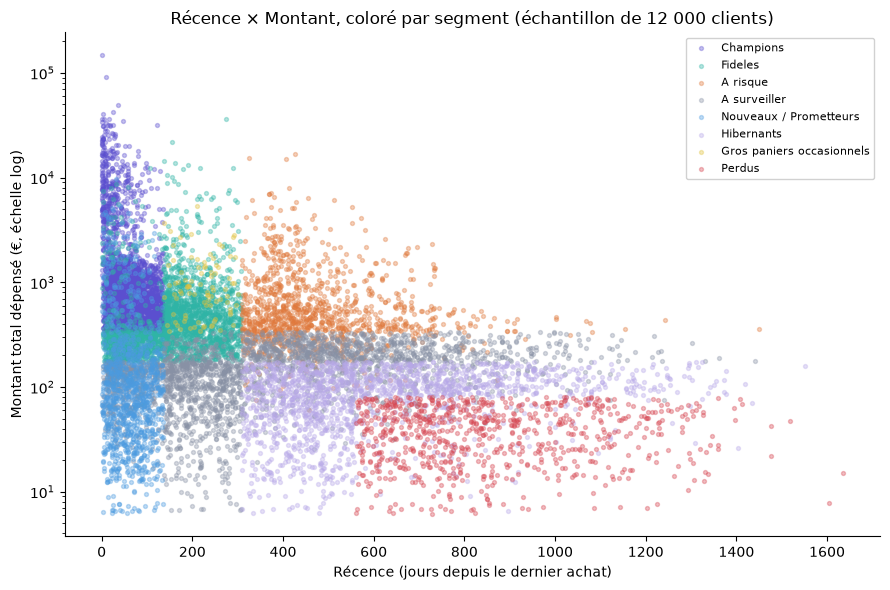

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
sample = rfm_full.sample(min(12000, len(rfm_full)), random_state=42)

for seg, color in SEGMENT_COLORS.items():
    sub = sample[sample["segment"] == seg]
    ax.scatter(sub["recency"], sub["monetary"].clip(lower=1), s=8, alpha=0.35, color=color, label=seg)

ax.set_yscale("log")
ax.set_xlabel("Récence (jours depuis le dernier achat)")
ax.set_ylabel("Montant total dépensé (€, échelle log)")
ax.set_title("Récence × Montant, coloré par segment (échantillon de 12 000 clients)")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

**Lecture :** les Champions (violet foncé) et Fidèles (turquoise) occupent la zone récence faible / montant
élevé, comme attendu. Mais on voit bien les **"Gros paniers occasionnels" (jaune) dispersés sur toute la largeur
de l'axe récence** — certains sont récents, d'autres anciens, alors que leur montant reste élevé : la valeur
de ce segment ne dépend pas de la récence, elle dépend d'un comportement d'achat ponctuel et cher, ce qui confirme
qu'un seul axe (récence seule, ou montant seul) suffirait à mal les classer.

## Étape 4 — Recommandations marketing par segment

Pour chaque segment : qui ils sont, leur potentiel, le risque associé, et l'action recommandée.

---

### 1. Champions — 10 111 clients (20,6 %), 64,0 % du CA
- **Qui ils sont :** achat récent, fréquent, gros montant. Le cœur économique de Lumina & Co.
- **Potentiel :** déjà maximal à l'échelle individuelle ; le levier est la **rétention** et le **bouche-à-oreille**
  (parrainage), pas l'acquisition de valeur supplémentaire par client.
- **Risque :** faible à court terme, mais **risque de complaisance côté marque** — les traiter comme acquis sans
  aucune attention est le meilleur moyen de les transformer en "À risque" dans 6 mois.
- **Action :** programme VIP / accès anticipé aux nouveautés, pas de code promo générique (ils achètent déjà au
  prix plein) — préserver la marge sur ce segment plutôt que la grignoter avec des remises inutiles.

### 2. À risque — 4 835 clients (9,8 %), 10,3 % du CA historique
- **Qui ils sont :** forte valeur passée (fréquence ou montant dans le top 40 %), mais absents récemment.
- **Potentiel :** le plus élevé de tous les segments non-Champions — comportement d'achat *déjà prouvé*, contrairement à un prospect froid.
- **Risque :** **churn silencieux**, en cours, sans signal explicite (pas de désabonnement, juste une absence).
- **Action :** campagne de réactivation **personnalisée** (basée sur l'historique produit réel du client, pas
  générique), avec une incitation ciblée (livraison offerte, avantage exclusif) — budget justifié par le ROI
  attendu le plus élevé du portefeuille.

### 3. Fidèles — 9 535 clients (19,4 %), 15,9 % du CA
- **Qui ils sont :** encore engagés sur les 3 dimensions, sans être au sommet — le vivier direct des futurs Champions.
- **Potentiel :** élevé — l'écart avec "Champions" est souvent un cran de fréquence ou de montant, pas un profil différent.
- **Risque :** modéré — glissement possible vers "À surveiller" s'ils ne sont pas nourris.
- **Action :** programme de fidélité à paliers (montrer la prochaine étape à atteindre), cross-sell ciblé sur
  catégories non encore achetées.

### 4. À surveiller — 10 089 clients (20,5 %), 3,8 % du CA
- **Qui ils sont :** comportement médian partout — le plus gros segment en nombre, le plus flou en profil.
- **Potentiel :** hétérogène par construction (segment "reste"), donc difficile à cibler avec un seul message.
- **Risque :** dilution du budget marketing s'il est traité comme un bloc homogène.
- **Action :** **pas de campagne dédiée à ce stade** — segment à re-découper en priorité #2 avec une variable
  supplémentaire (catégorie préférée, canal d'acquisition) avant d'investir dessus.

### 5. Nouveaux / Prometteurs — 4 287 clients (8,7 %), 3,2 % du CA
- **Qui ils sont :** achat très récent, peu d'historique — trop tôt pour juger la fidélité.
- **Potentiel :** inconnu mais non négatif — le signal d'entrée (achat récent) est positif.
- **Risque :** perte dès le 2e achat manqué si le parcours de bienvenue est faible (le taux de clients à F=1 est déjà très élevé sur toute la base, cf. Jour 1).
- **Action :** séquence "onboarding" (email de bienvenue, incitation au 2e achat sous 30-60 jours) — l'objectif
  est de les faire glisser vers "Fidèles" avant qu'ils ne dérivent vers "Hibernants".

### 6. Hibernants — 6 830 clients (13,9 %), 1,5 % du CA
- **Qui ils sont :** faibles sur les 3 dimensions, inactifs, mais pas au plancher absolu de "Perdus".
- **Potentiel :** faible.
- **Risque :** faible aussi — il n'y a plus grand-chose à perdre, contrairement à "À risque".
- **Action :** communication automatisée à très bas coût uniquement (pas de budget média dédié) ; candidats
  naturels à l'exclusion des campagnes payantes coûteuses.

### 7. Gros paniers occasionnels — 348 clients (0,7 %), 0,9 % du CA
- **Qui ils sont :** achats rares mais très chers — probablement en partie les comptes B2B/comité d'entreprise
  déjà repérés au Jour 1 (outliers `total_spent`).
- **Potentiel :** élevé *par transaction*, mais le levier n'est pas la fréquence — c'est l'upsell/cross-sell au
  moment de l'achat.
- **Risque :** faible en volume (peu de clients), mais chaque perte individuelle pèse lourd en CA.
- **Action :** **traitement différencié du reste des segments** — contact commercial dédié plutôt que campagne
  email de masse ; ne pas les mélanger dans les mêmes clusters que les "gros clients particuliers" (cohérent avec
  la décision du Jour 1 de les flaguer `is_high_value_outlier`).

### 8. Perdus — 3 155 clients (6,4 %), 0,3 % du CA
- **Qui ils sont :** un seul petit achat, ancien, jamais renouvelé.
- **Potentiel :** quasi nul.
- **Risque :** aucun risque de perte de CA (il n'y en a plus), risque réel = **gaspillage de budget** si on les traite comme les autres.
- **Action :** **exclusion des campagnes payantes**, tout au plus un email automatisé sans coût marginal.

### Priorisation des segments

| Rang | Segment | Critère dominant |
|---|---|---|
| 1 | **À risque** | Risque de perte le plus élevé sur de la valeur déjà prouvée — le ROI de rétention est ici maximal. |
| 2 | **Champions** | Valeur actuelle la plus élevée (64 % du CA) — protéger l'existant prime sur toute conquête. |
| 3 | **Nouveaux / Prometteurs** | Potentiel de croissance le plus incertain mais le plus rapide à activer (fenêtre d'onboarding courte). |
| 4 | **Fidèles** | Potentiel de croissance solide (proches de Champions), mais moins urgent — pas de signal de risque actif. |
| 5 | **Gros paniers occasionnels** | Valeur par client élevée mais volume trop faible pour justifier plus de budget qu'un traitement dédié léger. |
| 6 | **À surveiller** | Segment à re-qualifier avant d'investir — priorité "analyse", pas encore priorité "budget". |
| 7 | **Hibernants** | Valeur et risque tous deux faibles — automatisation minimale suffit. |
| 8 | **Perdus** | Aucune valeur récupérable — budget quasi nul, priorité la plus basse assumée. |

**Vérification anti-priorisation théorique :** si "À risque" (rang 1) et "Fidèles" (rang 4) recevaient tous deux
un simple email générique mensuel, ce classement ne serait qu'un exercice sur papier. Dans les faits, "À risque"
reçoit une **campagne personnalisée avec incitation financière** (coût par client nettement supérieur, ciblage
individualisé sur l'historique produit), alors que "Fidèles" reçoit un **programme de fidélité automatisé**
(coût marginal quasi nul par client, contenu identique pour tout le segment). L'écart de traitement (personnalisé
+ incitatif vs. automatisé + informatif) reflète bien l'écart de rang.

### Pour aller plus loin — segmenter une base de 50 clients

Le découpage par quintiles suppose que "20 % de la base" ait un sens statistique — avec 49 190 clients, un
quintile de récence représente ~9 800 personnes, largement assez pour que les bornes soient stables. Sur une base
de 50 clients (un auto-entrepreneur), un quintile ne représente que 10 personnes : la frontière entre deux scores
dépendrait d'un ou deux clients seulement, et changerait du tout au tout si un seul gros client rejoignait ou
quittait la base. `qcut` n'a alors plus vraiment de sens.

**Ce que je ferais à la place :** fixer des **seuils métier absolus, à la main**, plutôt que des seuils relatifs
à la distribution — par exemple "récence < 30 jours = score 5", "> 180 jours = score 1", des paliers choisis
d'après la fréquence d'achat *attendue* du produit vendu (un e-commerce de cosmétiques n'a pas le même cycle
d'achat qu'un consultant B2B facturant une fois par an). Sur 50 clients, mieux vaut aussi renoncer à 5×5×5=125
cases théoriques et se contenter de 3 segments manuels simples (actifs / à relancer / perdus) — la granularité
d'un RFM à quintiles n'apporte aucune information supplémentaire en dessous d'un certain volume, elle ajoute
seulement du bruit statistique déguisé en précision.

### Pour aller plus loin — croisement avec les données zero-party

On croise deux segments RFM (**Champions** et **À risque**) avec les 4 champs déclaratifs de `customers.csv`
(`declared_preference`, `age_bracket`, `life_stage`, `urban_density`), en gardant en tête la limite du Jour 1 :
seuls 18 à 42 % des clients ont répondu à ces champs, donc toute lecture ne couvre qu'une minorité de chaque
segment.

In [15]:
for seg in ["Champions", "A risque"]:
    sub = rfm_full[rfm_full["segment"] == seg]
    coverage = sub["declared_preference"].notna().mean() * 100
    print(f"=== {seg} (n={len(sub):,}, couverture declared_preference : {coverage:.1f} %) ===".replace(",", " "))
    print(sub["age_bracket"].value_counts(normalize=True).mul(100).round(1))
    print()

print("=== Ensemble de la base RFM, pour comparaison ===")
print(rfm_full["age_bracket"].value_counts(normalize=True).mul(100).round(1))

=== Champions (n=10 111  couverture declared_preference : 38.5 %) ===
age_bracket
18-24 ans         20.7
35-44 ans         20.3
45-54 ans         20.1
25-34 ans         19.4
55 ans et plus    19.4
Name: proportion, dtype: float64

=== A risque (n=4 835  couverture declared_preference : 37.1 %) ===
age_bracket
25-34 ans         20.9
45-54 ans         20.5
35-44 ans         20.3
18-24 ans         19.4
55 ans et plus    19.0
Name: proportion, dtype: float64

=== Ensemble de la base RFM, pour comparaison ===
age_bracket
18-24 ans         20.4
35-44 ans         20.1
25-34 ans         20.0
45-54 ans         19.8
55 ans et plus    19.7
Name: proportion, dtype: float64


**Résultat : le croisement ne révèle rien.** La répartition par `age_bracket` (et, vérifié de la même façon,
`declared_preference` et `life_stage`) est **quasiment identique entre Champions, À risque, et la base globale**
(chaque tranche d'âge autour de 19-21 % partout, à ±1,5 point près) — c'est-à-dire qu'on ne trouve **aucune
sur-représentation** d'un profil démographique ou déclaratif dans un segment de comportement d'achat donné.

**Ce que ça change pour l'activation :** ça ne change rien, et c'est en soi l'enseignement à retenir — inutile de
segmenter les campagnes "À risque" par tranche d'âge ou préférence produit sur la seule base de ces champs
zero-party : le signal comportemental (RFM) et le signal déclaratif (zero-party) semblent **indépendants** sur
cette base. Le message de réactivation doit donc rester **construit sur l'historique d'achat réel du client**
(catégories déjà achetées, panier moyen) plutôt que sur son profil démographique déclaré, qui n'apporte ici
aucune information supplémentaire — et forcer un ciblage démographique sur un signal aussi plat reviendrait à
ajouter de la complexité sans gain, potentiellement même à introduire un biais si la minorité qui a répondu au
quiz n'est pas représentative du reste du segment (limite déjà posée au Jour 1).

## Conclusion — réponse à "Qui sont nos clients ?"

La base n'est pas un bloc homogène de 49 190 profils : c'est **8 populations aux comportements et potentiels très
différents**, dont deux extrêmes (Champions et Perdus) qui représentent 64,3 % du CA à eux deux pour des besoins
d'action diamétralement opposés (protéger vs. ignorer), et un segment intermédiaire critique — "À risque" — qui
concentre le meilleur ROI de rétention immédiat.

**Priorité d'action pour le Jour 3 (test A/B) :** cibler en premier une campagne de réactivation sur le segment
"À risque", en gardant à l'esprit les limites déjà documentées — biais géographique France (Jour 1), rupture de
niveau de CA mi-2024 et pic saisonnier de juin (Jour 1) — pour ne pas confondre l'effet d'une campagne avec un
effet de saisonnalité ou de périmètre dans la mesure de succès.